Quiz 1：彩色影像轉灰階影像
實驗目的

本實驗的目的是將彩色影像轉換為灰階影像，並比較使用 OpenCV 與 NumPy 自行實作灰階轉換方法的差異。

實驗將比較兩種方法的：

執行速度
灰階影像轉換結果
兩種方法之間的像素差異


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
image = cv2.imread("data\IMG_1.jpg")

print("影像尺寸：", image.shape)
print("影像資料型態：", image.dtype)

影像尺寸： (879, 659, 3)
影像資料型態： uint8


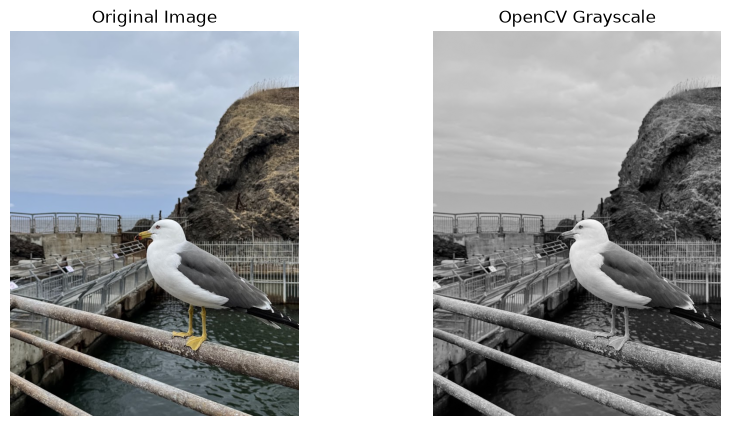

In [3]:
gray_cv = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_cv, cmap="gray")
plt.title("OpenCV Grayscale")
plt.axis("off")

plt.show()

## 1. 使用 NumPy 自行實作灰階轉換

OpenCV 讀取彩色影像時，色彩通道順序為 BGR。

灰階轉換使用加權平均的方式計算：

Gray = 0.299R + 0.587G + 0.114B

由於 OpenCV 使用 BGR 順序，因此在程式中分別取出 B、G、R 三個通道，再依照對應權重進行計算。


In [7]:
B = image[:, :, 0]
G = image[:, :, 1]
R = image[:, :, 2]
gray_np = 0.114 * B + 0.587 * G + 0.299 * R
gray_np = np.clip(gray_np, 0, 255).astype(np.uint8)
gray_np

array([[191, 191, 191, ..., 213, 213, 213],
       [191, 191, 191, ..., 213, 213, 213],
       [191, 191, 191, ..., 212, 212, 212],
       ...,
       [ 17,  15,  14, ...,  74,  75,  76],
       [ 16,  15,  15, ...,  81,  81,  80],
       [ 14,  15,  16, ...,  87,  85,  83]], shape=(879, 659), dtype=uint8)

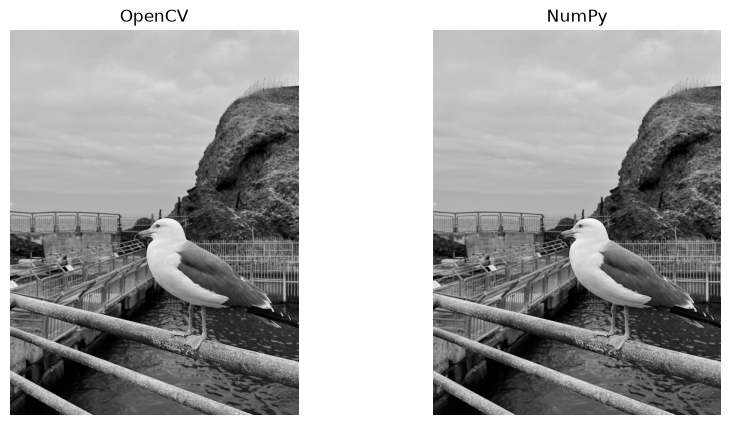

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_cv, cmap="gray")
plt.title("OpenCV")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_np, cmap="gray")
plt.title("NumPy")
plt.axis("off")

plt.show()

In [9]:
print("OpenCV dtype:", gray_cv.dtype)
print("NumPy dtype:", gray_np.dtype)

print("影像尺寸是否相同：", gray_cv.shape == gray_np.shape)
print("影像是否完全相同：", np.array_equal(gray_cv, gray_np))

OpenCV dtype: uint8
NumPy dtype: uint8
影像尺寸是否相同： True
影像是否完全相同： False
